 import all library pandas and requests and sql and matplotlib

In [44]:
import pandas as pd
import requests
import sqlite3
import matplotlib.pyplot as plt

I collected the data from the API, checked that the response was correct, and then converted the JSON data into Python data so I could clean and analyze it

In [45]:
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"
response = requests.get(url)
print(response.status_code)
print(response.json())
data = response.json()
df = pd.DataFrame(data["items"])


200
{'total_count': 1238037, 'incomplete_results': False, 'items': [{'id': 45717250, 'node_id': 'MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==', 'name': 'tensorflow', 'full_name': 'tensorflow/tensorflow', 'private': False, 'owner': {'login': 'tensorflow', 'id': 15658638, 'node_id': 'MDEyOk9yZ2FuaXphdGlvbjE1NjU4NjM4', 'avatar_url': 'https://avatars.githubusercontent.com/u/15658638?v=4', 'gravatar_id': '', 'url': 'https://api.github.com/users/tensorflow', 'html_url': 'https://github.com/tensorflow', 'followers_url': 'https://api.github.com/users/tensorflow/followers', 'following_url': 'https://api.github.com/users/tensorflow/following{/other_user}', 'gists_url': 'https://api.github.com/users/tensorflow/gists{/gist_id}', 'starred_url': 'https://api.github.com/users/tensorflow/starred{/owner}{/repo}', 'subscriptions_url': 'https://api.github.com/users/tensorflow/subscriptions', 'organizations_url': 'https://api.github.com/users/tensorflow/orgs', 'repos_url': 'https://api.github.com/users/tensorflow/rep

iam display the 5rows and the final 5rows and display the shape 100row and 3columns  and i want to know data use info

In [46]:
print(df.head())
print(df.tail())
print(df.shape)
print(df.info())

          id                           node_id                      name  \
0   45717250  MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==                tensorflow   
1  155220641  MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=              transformers   
2  343965132  MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=          ML-For-Beginners   
3  145553672  MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=                    funNLP   
4   21872392  MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==  awesome-machine-learning   

                               full_name  private  \
0                  tensorflow/tensorflow    False   
1               huggingface/transformers    False   
2             microsoft/ML-For-Beginners    False   
3                  fighting41love/funNLP    False   
4  josephmisiti/awesome-machine-learning    False   

                                               owner  \
0  {'login': 'tensorflow', 'id': 15658638, 'node_...   
1  {'login': 'huggingface', 'id': 25720743, 'node...   
2  {'login': 'microsoft', 'id': 6154722, 'node_id...   


I want to check if there are any missing or duplicate values.

In [53]:
print(df.isnull().sum())
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

name            0
owner           0
language        0
stars           0
forks           0
watchers        0
open_issues     0
created_date    0
updated_date    0
license         0
created_year    0
dtype: int64
0
0


Here, I selected the important values that I needed and used df = pd.DataFrame(data["items"]) to display them. I also worked with the owner, license, and index fields. Some values were undefined or missing, so I cleaned and fixed them.

In [48]:
df = df [
    [
        "name",
        "owner",
        "language",
        "stargazers_count",
        "forks_count",
        "watchers_count",
        "open_issues_count",
        "created_at",
        "updated_at",
        "license"
    ]]

df["owner"] = df["owner"].apply(lambda x: x["login"] if x else None)
df["license"] = df["license"].apply(lambda x: x["name"] if x else None)
print(df.isnull().sum())
df["language"] = df["language"].fillna("Unknown")
df["license"] = df["license"].fillna("Unknown")

print(df.isnull().sum())





name                  0
owner                 0
language             23
stargazers_count      0
forks_count           0
watchers_count        0
open_issues_count     0
created_at            0
updated_at            0
license              22
dtype: int64
name                 0
owner                0
language             0
stargazers_count     0
forks_count          0
watchers_count       0
open_issues_count    0
created_at           0
updated_at           0
license              0
dtype: int64


/tmp/ipykernel_2044/2925091096.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["owner"] = df["owner"].apply(lambda x: x["login"] if x else None)
/tmp/ipykernel_2044/2925091096.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["license"] = df["license"].apply(lambda x: x["name"] if x else None)
/tmp/ipykernel_2044/2925091096.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

iam verify to there missing value

In [49]:
print(df.isnull().sum())

name                 0
owner                0
language             0
stargazers_count     0
forks_count          0
watchers_count       0
open_issues_count    0
created_at           0
updated_at           0
license              0
dtype: int64


i edeting the e name to the lowest

In [50]:
df = df.rename(columns={
    "stargazers_count": "stars",
    "forks_count": "forks",
    "watchers_count": "watchers",
    "open_issues_count": "open_issues",
    "created_at": "created_date",
    "updated_at": "updated_date"
})

In [51]:
print(df.head())

                       name           owner          language   stars  forks  \
0                tensorflow      tensorflow               C++  197559  76115   
1              transformers     huggingface            Python  164402  34344   
2          ML-For-Beginners       microsoft  Jupyter Notebook   89752  22063   
3                    funNLP  fighting41love            Python   82640  15278   
4  awesome-machine-learning    josephmisiti            Python   74145  15621   

   watchers  open_issues          created_date          updated_date  \
0    197559         2929  2015-11-07T01:19:20Z  2026-08-24T22:10:26Z   
1    164402         2396  2018-10-29T13:56:00Z  2026-08-24T21:23:55Z   
2     89752           13  2021-03-03T01:34:05Z  2026-08-24T21:02:38Z   
3     82640           52  2018-08-21T11:20:39Z  2026-08-24T15:21:08Z   
4     74145           26  2014-07-15T19:11:19Z  2026-08-24T20:14:22Z   

              license  
0  Apache License 2.0  
1  Apache License 2.0  
2         MIT 

In [52]:
df["created_date"] = pd.to_datetime(df["created_date"])
df["updated_date"] = pd.to_datetime(df["updated_date"])
df["created_year"] = df["created_date"].dt.year

I converted the data into a CSV file

In [18]:
df.to_csv("github_projects.csv", index=False)
print(df.head())
print(df.shape)

          id                           node_id                      name  \
0   45717250  MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==                tensorflow   
1  155220641  MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=              transformers   
2  343965132  MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=          ML-For-Beginners   
3  145553672  MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=                    funNLP   
4   21872392  MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==  awesome-machine-learning   

                               full_name  private  \
0                  tensorflow/tensorflow    False   
1               huggingface/transformers    False   
2             microsoft/ML-For-Beginners    False   
3                  fighting41love/funNLP    False   
4  josephmisiti/awesome-machine-learning    False   

                                               owner  \
0  {'login': 'tensorflow', 'id': 15658638, 'node_...   
1  {'login': 'huggingface', 'id': 25720743, 'node...   
2  {'login': 'microsoft', 'id': 6154722, 'node_id...   


I converted the data from a CSV file to an SQL table.

In [55]:
import sqlite3
df = pd.read_csv("github_projects.csv")
conn = sqlite3.connect("github_projects.db")
df.to_sql("Repositories", conn, if_exists="replace", index=False)
print(df.head())
print(df.shape)

          id                           node_id                      name  \
0   45717250  MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==                tensorflow   
1  155220641  MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=              transformers   
2  343965132  MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=          ML-For-Beginners   
3  145553672  MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=                    funNLP   
4   21872392  MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==  awesome-machine-learning   

                               full_name  private  \
0                  tensorflow/tensorflow    False   
1               huggingface/transformers    False   
2             microsoft/ML-For-Beginners    False   
3                  fighting41love/funNLP    False   
4  josephmisiti/awesome-machine-learning    False   

                                               owner  \
0  {'login': 'tensorflow', 'id': 15658638, 'node_...   
1  {'login': 'huggingface', 'id': 25720743, 'node...   
2  {'login': 'microsoft', 'id': 6154722, 'node_id...   


i edeting the names

In [23]:
df = df.rename(columns={
    "stargazers_count": "stars",
    "forks_count": "forks",
    "watchers_count": "watchers",
    "open_issues_count": "open_issues",
    "created_at": "created_date",
    "updated_at": "updated_date"
})

i make the if condition using sql i want to saw stars > 10000

In [24]:
query = """
SELECT *
FROM Repositories
WHERE stars > 10000;
"""
result = pd.read_sql(query, conn)
print(result)

           id                           node_id  \
0    45717250  MDEwOlJlcG9zaXRvcnk0NTcxNzI1MA==   
1   155220641  MDEwOlJlcG9zaXRvcnkxNTUyMjA2NDE=   
2   343965132  MDEwOlJlcG9zaXRvcnkzNDM5NjUxMzI=   
3   145553672  MDEwOlJlcG9zaXRvcnkxNDU1NTM2NzI=   
4    21872392  MDEwOlJlcG9zaXRvcnkyMTg3MjM5Mg==   
..        ...                               ...   
65  223824546  MDEwOlJlcG9zaXRvcnkyMjM4MjQ1NDY=   
66   86140645  MDEwOlJlcG9zaXRvcnk4NjE0MDY0NQ==   
67  121647248  MDEwOlJlcG9zaXRvcnkxMjE2NDcyNDg=   
68  100120455  MDEwOlJlcG9zaXRvcnkxMDAxMjA0NTU=   
69   45495679  MDEwOlJlcG9zaXRvcnk0NTQ5NTY3OQ==   

                               name  \
0                        tensorflow   
1                      transformers   
2                  ML-For-Beginners   
3                            funNLP   
4          awesome-machine-learning   
..                              ...   
65  machine-learning-systems-design   
66                 Machine-Learning   
67           machine-learning-notes 

i want to display the states contain the word machine

In [ ]:
quere = """
select *
from Repositories
where name LIKE "%machine%"
"""
result = pd.read_sql(quere, conn)
print(result)

in there i use 2 if condition stars >6000 and forks < 4000

In [ ]:
quere = """
select *
from Repositories
where stars > 6000 And forks < 4000 """
result = pd.read_sql(quere, conn)
print(result)


in there i use 2 if condition

In [ ]:
quere = """
select *
from Repositories
where watchers < 10000 or forks > 5000 """
result = pd.read_sql(quere, conn)
print(result)

iam use where not to saw the language not javascript

In [ ]:
quere = """
select *
from Repositories
WHERE NOT language = "JavaScript" """
result = pd.read_sql(quere, conn)
print(result)

iam sorting the stars to the hiesght value to lower value

In [ ]:
quere = """
select *
from Repositories
ORDER BY stars DESC """
result = pd.read_sql(quere, conn)
print(result)

iam sorting the forks to hiesght value to lower value

In [ ]:
quere = """
select *
from Repositories
ORDER BY forks DESC """
result = pd.read_sql(quere, conn)
print(result)

iam sorting the watchers from hieght value to lower value

In [ ]:
quere = """
select *
from Repositories
ORDER BY watchers DESC """
result = pd.read_sql(quere, conn)
print(result)

iam sorting the forks and display the frist 10

In [ ]:
quere = """
select *
from Repositories
ORDER BY forks DESC
limit 10 """
result = pd.read_sql(quere, conn)
print(result)

iam using count

In [ ]:
quere = """
select count (*) as total_repositories
from Repositories """
result = pd.read_sql(quere, conn)
print(result)


iam using average

In [ ]:
quere = """
select avg(stars) as average_stars
from repositories"""
result = pd.read_sql(quere, conn)
print(result)

The dataset contains 100 GitHub repositories, with an average of approximately 20,827.69 stars per repository, indicating that the collected Machine Learning repositories have a relatively high level of popularity.

In [ ]:
quere = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
WHERE language != 'Unknown'
GROUP BY language
HAVING COUNT(*) > 5; """
result = pd.read_sql(quere, conn)
print(result)

i delete the unknown value to display the language i saw the python ia the frist and second jupeter notebook and third is c++

I sorted them from highest to lowest, created a bar chart, rotated the labels 45 degrees to make them easier to read, and adjusted the spacing to make the chart look better.

In [ ]:
top_10 = df.sort_values("stars", ascending=False).head(10)
plt.figure(figsize=(12, 6))
plt.bar(top_10["name"], top_10["stars"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Repository")
plt.ylabel("Stars")
plt.title("Top 10 Most Popular Repositories")
plt.tight_layout()
plt.show()

insight

Repository popularity is highly concentrated. TensorFlow is the most popular repository with nearly 200,000 stars, followed by Transformers with around 160,000 stars.

I adjusted the date and grouped it by year to make it easier to read. I also created a chart to visualize the dates and identify the highest and lowest values and their order.

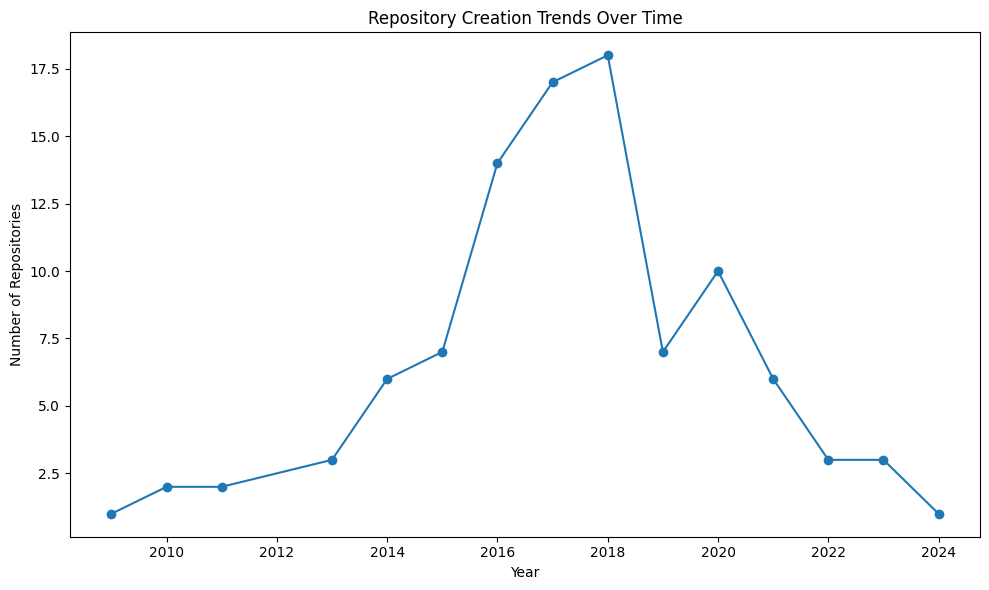

In [54]:
yearly_repositories = df["created_year"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.plot(yearly_repositories.index, yearly_repositories.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Repositories")
plt.title("Repository Creation Trends Over Time")
plt.tight_layout()
plt.show()

insight

Repository creation peaked in 2018, with approximately 18 repositories created that year. After 2018, the number of newly created repositories generally decreased, with a smaller increase in 2020

recomindation

Focus on Python-based Machine Learning projects, since Python is the most common language in the analyzed repositories.

Use highly popular repositories such as TensorFlow and Transformers as benchmarks when evaluating Machine Learning projects, because they have significantly higher numbers of stars.

Monitor repository activity and popularity over time to identify emerging Machine Learning projects instead of focusing only on older popular repositories.

Investigate the reasons behind the high popularity of leading repositories, such as community engagement, documentation, functionality, and ongoing development, to help improve future projects

Why is it important to verify data collected from public APIs?

Why should data analysts document the source of their data?

How can missing or inaccurate data affect data analysis and decision-making?

*anser the qustion

Since public APIs can return incomplete data (missing values)—and the data often changes or updates continuously, potentially containing errors or anomalies—data validation ensures that any analysis built upon it is accurate and reliable, preventing misleading results.

Transparency: Anyone reviewing your work should be able to trace the data's origin and assess its reliability. Reproducibility: If someone wants to replicate the analysis, they need to know the exact source details (API endpoint, collection date, any filters applied). Legal/Ethical Responsibility: Some APIs have Terms of Service that dictate how the data may be used.

It yields misleading insights, potentially leading to flawed decisions based on the analysis and undermining the credibility of the entire process. In the context of automation or data pipelines, erroneous data can "leak" and impact other analyses that rely on it.